### 1. Prerequisitos

#### 1.1 Paquetes
Instalación de paquetes requeridos para la ejecución adecuada del Notebook

In [4]:
!pip install --quiet -r requirements.txt

#### 1.2 Librerías
Importación de librerías requeridas para la ejecución adecuada del Notebook

In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
from joblib import dump
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import  TfidfVectorizer
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix,  classification_report
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier

#### 1.3 Variables comúnes
Asignación de variables que son utilizadas en diferentes puntos del Notebook

In [7]:
RANDOM_SEED = 42
DATA_PREPR = Path("./data-sources/pre-processed")
MODEL_PATH = Path("./models/tfidf")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

### 2. Datos

#### 2.1 Carga de datos
Carga de los datos a ser utilizados para el entrenamiento de los modelos

In [9]:
csv_files = sorted(DATA_PREPR.glob("data_chunk_*.csv"))
df_list = []
for f in csv_files:
    df_part = pd.read_csv(f)
    df_list.append(df_part)
data = pd.concat(df_list, ignore_index=True)
print(f'Registros totales cargados: {len(data)}')

Registros totales cargados: 58963


#### 2.2 Distribución
Distribución de los datos por cada uno de sus grupos (Texto Cientifico y PLS)

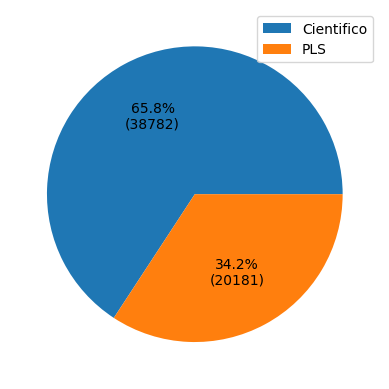

In [10]:
def autopct_format(values):
        def my_format(pct):
            total = sum(values)
            val = int(round(pct*total/100.0))
            return '{:.1f}%\n({v:d})'.format(pct, v=val)
        return my_format

pls_label = {0: 'Cientifico',1: 'PLS'}

df_temp = data.groupby(['pls']).size().to_frame(name='count').reset_index()
df_temp['pls'] = df_temp['pls'].replace(pls_label)

plt.pie(df_temp['count'],autopct=autopct_format(df_temp['count']))
plt.legend(df_temp['pls'])
plt.show()

#### 2.3 División de los datos
División de datos en Entrenamiento, Test y Validación, sus porcentajes son 70%, 15% y 15% respectivamente

In [11]:
df_train, df_temp = train_test_split(data, test_size=0.3,random_state=RANDOM_SEED,stratify=data['pls'])
df_test, df_val = train_test_split(df_temp,test_size=0.5,random_state=RANDOM_SEED,stratify=df_temp['pls'])

x_train,y_train = df_train['text'],df_train['pls']
x_test,y_test = df_test['text'],df_test['pls']
x_val,y_val = df_val['text'],df_val['pls']

print(f'Cantidad de registros dataset entrenamiento: {len(df_train)}, porcentaje {len(df_train)/len(data):.0%}')
print(f'Cantidad de registros dataset validación: {len(df_val)}, porcentaje {len(df_val)/len(data):.0%}')
print(f'Cantidad de registros dataset test: {len(df_test)}, porcentaje {len(df_test)/len(data):.0%}')

Cantidad de registros dataset entrenamiento: 41274, porcentaje 70%
Cantidad de registros dataset validación: 8845, porcentaje 15%
Cantidad de registros dataset test: 8844, porcentaje 15%


### 3. Entrenamiento

#### 3.1 Clases requeridas
Definición de la clase `TextPreprocessor` para realizar la tokenizacion del texto y su limpieza.

In [15]:
class TextPreprocessor():

    def clean_light_text(self, text):
        text = re.sub(r'([\(\)"“”‘’!?.,:;()&^%$#@\-_\[\]\*])', r' \1 ', text)
        text = re.sub(r'\n+', ' ', text)
        return text
    
    def tokenize(self, text):
        return text.split()

Calculo de la proporción de balanceo en las clases

In [12]:
c_classes = np.unique(y_train)
c_weight=compute_class_weight(class_weight="balanced", classes=c_classes, y=y_train)
dict_weight = {}
for A, B in zip(c_classes, c_weight):
    dict_weight[int(A)] = float(B)

print(dict_weight)

{0: 0.7601944966294618, 1: 1.4608197069441495}


Definición del pipeline para el entrenamiento: Modelos y su parametrización, para el entrenamiento se consideraron los algoritmos:   
- LinearSVC
- LogisticRegression
- RandomForestClassifier
- SGDClassifier

In [18]:
text_processor = TextPreprocessor()
pipeline = Pipeline([
    ('vect', TfidfVectorizer()),
    ('clf',LinearSVC())
    ])

tfid_block = {
    'vect__ngram_range': [(1, 2)],
    'vect__max_df': [0.8],
    'vect__min_df': [1],
    'vect__preprocessor': [text_processor.clean_light_text],
    'vect__tokenizer': [text_processor.tokenize],
    'vect__strip_accents': ['ascii'],
    'vect__token_pattern': [None],
}

param_grid = [
    {
        'clf': [LinearSVC()],
        'clf__C': [1],#[1, 2, 0.5]
        'clf__class_weight': [dict_weight],
        **tfid_block
    },
    {
        'clf': [LogisticRegression(max_iter=500)],
        'clf__solver': ['liblinear', 'saga'],
        'clf__penalty': ['l2'],
        'clf__C': [1],#[1.0, 0.5, 2.0]
        'clf__class_weight': [dict_weight],
        **tfid_block
    },
    {
        'clf': [RandomForestClassifier(random_state=RANDOM_SEED)],
        'clf__n_estimators': [300, 500],
        'clf__max_depth': [None, 20, 40],
        'clf__min_samples_split': [2, 5],
        'clf__class_weight': [dict_weight],
        **tfid_block
    },
    {
        'clf': [SGDClassifier(random_state=RANDOM_SEED)],
        'clf__loss': ['hinge', 'log_loss'],
        'clf__alpha': [1e-4, 5e-5, 1e-5],
        'clf__penalty': ['l2'],
        'clf__class_weight': [dict_weight],
        **tfid_block
    },
]

grid_search = GridSearchCV(pipeline, param_grid=param_grid, cv=5, scoring='f1_macro',verbose=2,n_jobs=6)
grid_search.fit(x_train, y_train)
y_pred = grid_search.predict(x_test)

print("Mejores Hiperparámetros: ", grid_search.best_params_)
print("Mejor puntaje de validación cruzada: {:.5f}".format(grid_search.best_score_))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END clf=LinearSVC(), clf__C=1, clf__class_weight={0: 0.7601944966294618, 1: 1.4608197069441495}, vect__max_df=0.8, vect__min_df=1, vect__ngram_range=(1, 2), vect__preprocessor=<bound method TextPreprocessor.clean_light_text of <__main__.TextPreprocessor object at 0x12e4442c0>>, vect__strip_accents=ascii, vect__token_pattern=None, vect__tokenizer=<bound method TextPreprocessor.tokenize of <__main__.TextPreprocessor object at 0x12e4442c0>>; total time=  37.8s
[CV] END clf=LinearSVC(), clf__C=1, clf__class_weight={0: 0.7601944966294618, 1: 1.4608197069441495}, vect__max_df=0.8, vect__min_df=1, vect__ngram_range=(1, 2), vect__preprocessor=<bound method TextPreprocessor.clean_light_text of <__main__.TextPreprocessor object at 0x132aa07a0>>, vect__strip_accents=ascii, vect__token_pattern=None, vect__tokenizer=<bound method TextPreprocessor.tokenize of <__main__.TextPreprocessor object at 0x132aa07a0>>; total time=  38.0s
[CV]

El mejor modelo encontrado por medio de GridSearchCV es un **SGDClassifier**, esta es la matriz de confusion resultante

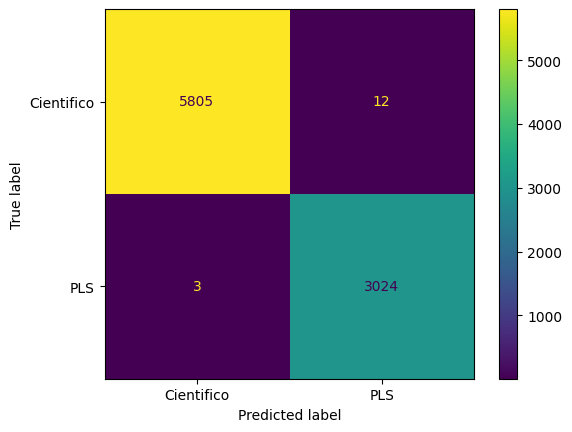

In [19]:
conf_mtx = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_mtx,display_labels=['Cientifico', 'PLS'])
disp.plot()
plt.show()

In [20]:
print(classification_report(y_test, y_pred,digits=4))

              precision    recall  f1-score   support

           0     0.9995    0.9979    0.9987      5817
           1     0.9960    0.9990    0.9975      3027

    accuracy                         0.9983      8844
   macro avg     0.9978    0.9985    0.9981      8844
weighted avg     0.9983    0.9983    0.9983      8844



In [21]:
y_pred_eval = grid_search.predict(x_val)
print(classification_report(y_val, y_pred_eval,digits=4))

              precision    recall  f1-score   support

           0     0.9997    0.9988    0.9992      5818
           1     0.9977    0.9993    0.9985      3027

    accuracy                         0.9990      8845
   macro avg     0.9987    0.9991    0.9989      8845
weighted avg     0.9990    0.9990    0.9990      8845



In [22]:
print(x_val.iloc[5])
print(f'Valor Original: {y_val.iloc[5]}')
print(f'Valor Predicho: {grid_search.predict(x_val.iloc[[5]])}')

Background
The risk of cytomegalovirus (CMV) infection in solid organ transplant recipients has resulted in the frequent use of prophylaxis with the aim of preventing the clinical syndrome associated with CMV infection. This is an update of a review first published in 2005 and updated in 2008. 
Objectives
To determine the benefits and harms of antiviral medications to prevent CMV disease and all‐cause mortality in solid organ transplant recipients. 
Search methods
We searched MEDLINE, EMBASE and the Cochrane Central Registry of Controlled Trials (CENTRAL) in The Cochrane Library to February 2004 for the first version of this review. The Cochrane Renal Group's specialised register was searched to February 2007 and to July 2011 for the first and current updates of the review without language restriction. 
Selection criteria
We included randomised controlled trials (RCTs) and quasi‐RCTs comparing antiviral medications with placebo or no treatment, comparing different antiviral medications

Se guarda el modelo en la ruta **models/tfidf**

In [23]:
best_model = grid_search.best_estimator_
dump(best_model, MODEL_PATH/"best_model.joblib")  

['models/tfidf/best_model.joblib']